In [2]:
#Question 1
import pandas as pd
    
exc = pd.ExcelFile("Pays_projet.xlsx")
df = pd.read_excel(exc)
data = df.iloc[1:,1:].values  # on ne prend pas la premiere ligne ni la premiere colonne

print(data)

[[8.6 7.89 9.17 8.89 3.98 9.57 9.84 9.05 9.37 8.75 9.25]
 [8.3 9.18 9.27 10 5 9.9 7.9 6.66 8.25 8.75 9.08]
 [7.6 9.64 7.57 8.2 5 9.45 7.34 6.19 8.25 9 8.53]
 [8.1 9.85 9 8.59 0.93 8.2 6.59 6.64 10 7.5 7.66]
 [7.94 8.5 8.26 7.04 4.52 7.91 6.92 6.39 9.3 7.71 8.41]
 [4.9 6.03 5.26 0 7.04 4.62 3.29 3.31 8.31 0 6.94]
 [7.1 5.36 5.24 8.56 7.91 6.68 6.85 7.33 8.73 7.5 7.28]
 [7.9 9.95 7.36 6.1 5.87 7.41 7.38 5.14 7.63 8.06 5.12]
 [7.7 9.69 9.14 0.18 1.7 8.37 6.56 6.17 8.81 10 8.5]
 [5.4 8.81 8.94 7.71 9.5 4.82 4.68 5.18 6.01 6.25 8.4]
 [6.5 7.84 7.06 5.37 9.84 5.18 3.82 6.85 10 4.19 8.03]
 [5.9 4.9 8.38 6.87 7.26 4.27 4.69 5.52 10 6.25 8.47]
 [7.1 5.41 7.96 6.87 5.51 4.78 4.88 3.7 9.58 7.5 8.26]
 [7 8.35 9.35 9.22 7.43 4.79 0.42 2.29 9.42 7.5 5.25]
 [5.2 7.99 7.66 8.81 8.97 4.17 0.63 2.3 10 7.49 7.67]
 [7.1 8.04 8.45 7.38 6.57 4.7 3 2.2 10 5 8.25]
 [5.8 3.81 6.91 6.87 8.85 3.24 4.39 5.86 10 7.19 6.68]
 [8.2 8.2 7.98 6.37 3.67 7.21 5.77 4.38 1.86 5 4.52]
 [5.6 9.79 4.63 7.09 6.92 4.22 1.66 2.9

In [3]:
#Question 3 (pour la #Question 2 voir rapport)
#On doit determiner si x Pareto-domine y, pour cela on a des conditions:
def pareto_domine(X, Y):
    superieur = True
    strictement_superieur = False
    
    for i in range(len(X)):
        if X[i] < Y[i]:                          #i) Condition 1: Pour tout i, x[i] >= y[i]
            superieur = False                    #des que la condition 1 n'est pas verifie, on return False
        if X[i] > Y[i]:                          
            strictement_superieur = True         #ii) Condition 2: Il existe au moins un i tel que x[i] > y[i]

    return superieur and strictement_superieur   #donc renvoie True si x domine y, False sinon.



In [3]:
#Question 4
"""
Pour formaliser cela informatiquement, on considere que 'relation' est une matrice de relation binaire de taille n×n, où :
relation[i][j] == True donc egale a 1 signifie que i Pareto-domine j,
relation[i][j] == False, sinon.
"""

def irreflexive(relation):
    """
    On veut que verifier si la relation est irreflexive, pour cela aucun pays ne doit se dominer lui-meme : 
    donc pour tout i, on doit avoir relation[i][i] == 0.
    """
    n = len(relation)
    for i in range(n):
        if relation[i][i] != 0:                 
            return False
    return True


def asymetrique(relation):
    """
    On veut verifier si la la relation est asymetrique, pour cela : 
    si on a relation[i][j] == 1 pour i ≠ j, alors on doit avoir relation[j][i]=0.
    """
    n = len(relation)
    for i in range(n):
        for j in range(n):
            if i != j and relation[i][j] == 1 and relation[j][i] == 1:     
                return False           #si la condition n'est pas verifiee, on return False
    return True


def transitive(relation):
    """
    On veut verifier si la relation est transitive, pour cela :
    Si pour tous i, j, k, on a relation[i][j] == 1 et relation[j][k] == 1 alors on doit avoir relation[i][k]= 1.
    """
    n = len(relation)
    for i in range(n):
        for j in range(n):
            for k in range(n):
                if relation[i][j] == 1 and relation[j][k] == 1:
                    if relation[i][k] != 1:     #si on a pas relation[i][k]= 1 alors ce n'est pas transitive et on return False
                        return False
    return True




In [4]:
#Question 5
#On cree une fonction qui calcule le pourcentage de dominance de Pareto sur toutes les paires (X ≠ Y).
#Ici on propose deux version possibles, voir le rapport pour l'explication détaillee. 
def pourcentage_pareto_domine(data):
    n = len(data)
    paire_total = n*(n-1)//2  #alternative : paire_total = 0
    compteur_dominante = 0

    for i in range(n):
        for j in range(n):
            if i != j:
                #paire_total += 1  c'est l'autre alternative
                if pareto_domine(data[i], data[j]):  #on reutilise notre fonction pareto_domine pour le teste
                    compteur_dominante += 1          #si il y a domination, on rajoute +1 au compteur 
    return (compteur_dominante / paire_total) * 100


#Exemple avec notre data issu du fichier Excel
res = pourcentage_pareto_domine(data)
print("Taux de dominance sur les 11 critères:", res)





Taux de dominance sur les 11 critères: 2.8205128205128207


In [5]:
#Ici on cree une fonction qui calcule le pourcentage de dominance de Pareto sur toutes les paires (X ≠ Y),
#mais seulement sur 3 criteres.
def pourcentage_pareto_domine_3Criteres(data, indices=[2, 8, 9]):
    
    data_reduite = data[:, indices] #on selectionne les 3 criteres
    n = len(data_reduite)
    paire_total = n*(n-1)//2   # alternative possible paire_total = 0
    compteur_dominante = 0

    for i in range(n):
        for j in range(n):
            if i != j:
                #paire_total += 1
                if pareto_domine(data_reduite[i], data_reduite[j]):
                    compteur_dominante += 1

    return (compteur_dominante / paire_total) * 100



#Exemple avec notre data issu du fichier Excel sur 3 criteres
res1 = pourcentage_pareto_domine_3Criteres(data)
print("Taux de dominance sur 3 criteres (criminalité, terrorisme, conflits violents) :",res1)


Taux de dominance sur 3 criteres (criminalité, terrorisme, conflits violents) : 51.41025641025641


In [6]:
#Question 6
import matplotlib.pyplot as plt

#Etape 1: On prepare les donnees: 

exc = pd.ExcelFile("Pays_Projet.xlsx")
df = pd.read_excel(exc)    #ici on garde tout le fichier comme tel

# On extrait seulement les colonnes correspondant aux 3 criteres
changement_climatique = df.iloc[1:, 1].values  # Colonne 1 
criminalite = df.iloc[1:, 3].values  # Colonne 3 
insecurite_energetique = df.iloc[1:, 5].values  # Colonne 5 



# On cree un nouveau data a l'aide de DataFrame
data = pd.DataFrame({
    "Changement climatique": changement_climatique,
    "Insécurité énergétique": insecurite_energetique,
    "Criminalité": criminalite
})


In [7]:
#Etape 2 : on determine les fronts Pareto (pays domines par aucun autre pays) : 
def front_pareto(data):
    pareto_front = []      #liste vide qu'on va remplir

    for i in range(len(data)):
        domine = False   #on initialise en false pour dire que le pays n'est encore domine par aucun autre pays
        for j in range(len(data)):
                if i != j and pareto_domine(data.iloc[j], data.iloc[i]):  #on utilise notre fonction pour le teste
                    domine = True      #si un pays est domine juste une fois, alors il est elimine donc on n'ajoute pas dans la liste
                    break
        if not domine:              #si domine est false, donc le pays est domine par aucun pays, on l'ajoute dans la liste
            pareto_front.append(data.iloc[i])

    return pd.DataFrame(pareto_front)


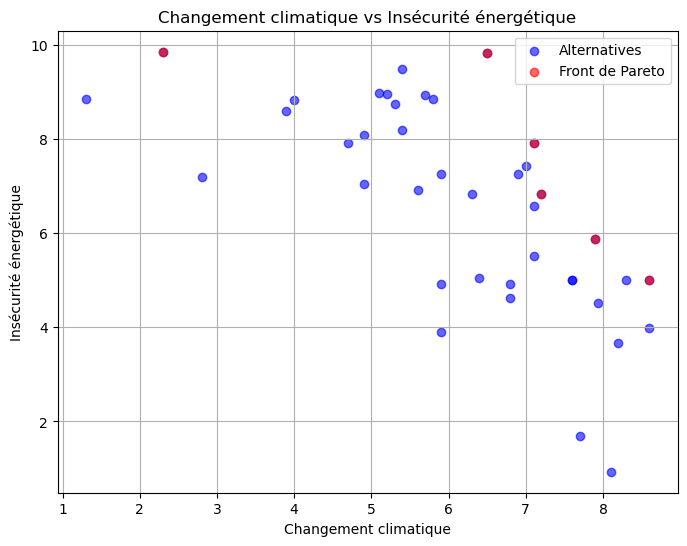

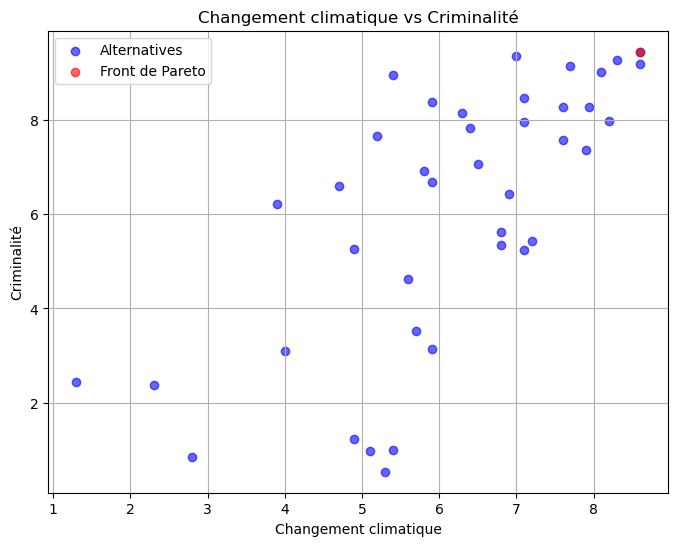

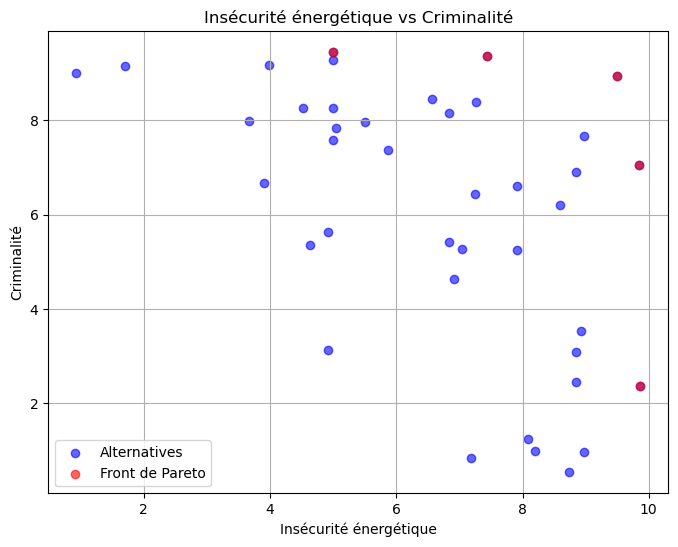

In [8]:
#Graphe 1
# On extrait uniquement deux critieres
pair_1 = data[["Changement climatique", "Insécurité énergétique"]]

# Calcul du front de Pareto pour ces 2 criteres
pareto_front_1 = front_pareto(pair_1)

# On trace le graphique
plt.figure(figsize=(8, 6))
plt.scatter(pair_1["Changement climatique"], pair_1["Insécurité énergétique"],
            color="blue", label="Alternatives", alpha=0.6)
plt.scatter(pareto_front_1["Changement climatique"], pareto_front_1["Insécurité énergétique"],
            color="red", label="Front de Pareto", alpha=0.6)
plt.xlabel("Changement climatique")
plt.ylabel("Insécurité énergétique")
plt.title("Changement climatique vs Insécurité énergétique")
plt.legend()
plt.grid(True)
plt.show()

#Graphe 2 (meme chose)
pair_2 = data[["Changement climatique", "Criminalité"]]
pareto_front_2 = front_pareto(pair_2)

plt.figure(figsize=(8, 6))
plt.scatter(pair_2["Changement climatique"],pair_2["Criminalité"],
            color="blue", label="Alternatives", alpha=0.6)
plt.scatter(pareto_front_2["Changement climatique"], pareto_front_2["Criminalité"],
            color="red", label="Front de Pareto", alpha=0.6)
plt.xlabel("Changement climatique")
plt.ylabel("Criminalité")
plt.title("Changement climatique vs Criminalité")
plt.legend()
plt.grid(True)
plt.show()


#Graphe 3 (meme chose)
pair_3 = data[["Insécurité énergétique", "Criminalité"]]
pareto_front_3 = front_pareto(pair_3)

plt.figure(figsize=(8, 6))
plt.scatter(pair_3["Insécurité énergétique"], pair_3["Criminalité"],
            color="blue", label="Alternatives", alpha=0.6)
plt.scatter(pareto_front_3["Insécurité énergétique"], pareto_front_3["Criminalité"],
            color="red", label="Front de Pareto", alpha=0.6)
plt.xlabel("Insécurité énergétique")
plt.ylabel("Criminalité")
plt.title("Insécurité énergétique vs Criminalité")
plt.legend()
plt.grid(True)
plt.show()


In [9]:
#Partie 2
#Question 8 (et pour la #Question 7 voir rapport)
from mip import Model, xsum, minimize


def L1_inv(X, Y): 
    
    n = len(X)  # ici n est suppose etre 11
    w_chapeau = 1.0 / n     #w_chapeau = (1/11, ..., 1/11) est le jeu de poids uniforme.
    model = Model(sense=minimize, solver_name="CBC")

    # On cree des variables de poids w_i
    w = [model.add_var(lb=0, name=f"w_{i}") for i in range(n)]  #condition: w_i >= 0 
    #On cree les variables auxiliaires pour la norme L1
    delta = [model.add_var(lb=0, name=f"delta_{i}") for i in range(n)] #condition: delta_i >=0
    
    # premiere contrainte de normalisation : somme des poids = 1
    model += xsum(w[i] for i in range(n)) == 1  #sum(w) = 1,

    # contraintes pour lineariser la norme L1 
    for i in range(n):
        model += delta[i] >= w[i] - w_chapeau
        model += delta[i] >= -(w[i] - w_chapeau)

    # contrainte de comparaison des scores : SPw(X) <= SPw(Y)
    model += xsum(w[i]*(X[i] - Y[i]) for i in range(n)) <= 0   # soit sum w_i * (X[i] - Y[i]) <= 0

    # On definit la fonction objectif : minimiser la somme des delta_i (norme L1)
    model.objective = minimize(xsum(delta[i] for i in range(n)))

    # resolution du modele
    model.optimize()


    if model.num_solutions:
        # on recupere le vecteur w optimise
        w_opt = [w[i].x for i in range(n)]
        return w_opt, model.objective_value     # on retourne le w_opt et une valeur optimale du programme lineaire.
    else:
        return None, None


# Exemple avec notre data 
exc = pd.ExcelFile("Pays_projet.xlsx")
df = pd.read_excel(exc)
data2 = df.iloc[1:,1:].values


for i in range(2):
    for j in range(3):
        if i !=j:
            w, opt_val = L1_inv(data2[i], data2[j])
            print("w=",w)
            print("Valeur optimale :", opt_val)
            print("\n")









w= [0.09090909090909091, 0.1420454545454543, 0.09090909090909091, 0.09090909090909093, 0.09090909090909091, 0.0909090909090909, 0.09090909090909093, 0.03977272727272721, 0.09090909090909091, 0.09090909090909091, 0.0909090909090909]
Valeur optimale : 0.10227272727272713


w= [0.0909090909090909, 0.2455614973262032, 0.09090909090909091, 0.09090909090909091, 0.09090909090909091, 0.09090909090909091, 0.02716577540106953, 0.0, 0.09090909090909091, 0.09090909090909093, 0.09090909090909091]
Valeur optimale : 0.3093048128342245


w= [0.09090909090909091, 0.0909090909090909, 0.09090909090909091, 0.09090909090909093, 0.09090909090909091, 0.0909090909090909, 0.09090909090909093, 0.09090909090909091, 0.09090909090909091, 0.09090909090909091, 0.0909090909090909]
Valeur optimale : 0.0


w= [0.004702194357366779, 0.35893416927899663, 0.0, 0.0, 0.09090909090909091, 0.09090909090909093, 0.09090909090909091, 0.0909090909090909, 0.09090909090909091, 0.09090909090909091, 0.09090909090909091]
Valeur optima

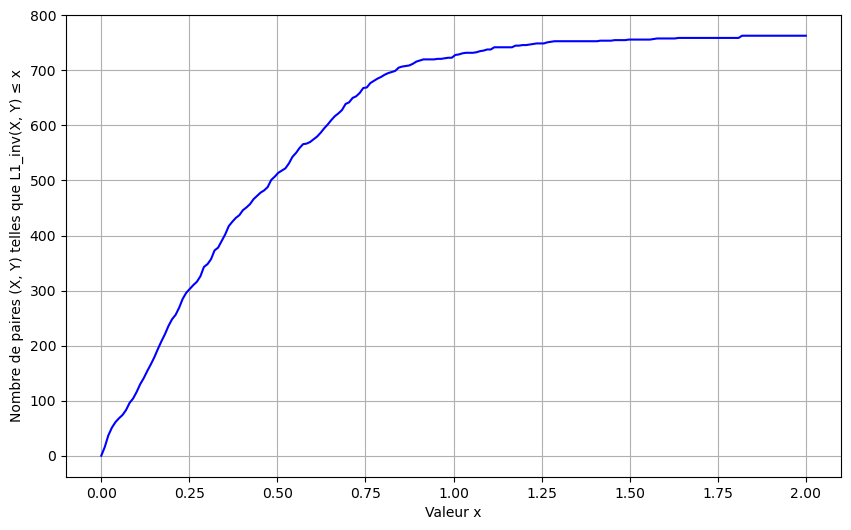

In [10]:
#Question 9
import numpy as np

n = len(data)
w_chapeau = [1/11 for i in range(11)]

# Liste des valeurs L1_inv pour les paires ou SP_w_chapeau(X) > SP_w_chapeau(Y)
Liste_L1 = []
for i in range(n):
    for j in range(n):
        if i != j:
            X = data2[i]
            Y = data2[j]
            sp_x = np.dot(w_chapeau, X) #c'est juste la somme ponderee
            sp_y = np.dot(w_chapeau, Y) #idem
            if sp_x > sp_y:
                w, val = L1_inv(X, Y)
                if val is not None:
                    Liste_L1.append(val)

# On trace le graphe
x_vals = np.linspace(0, 2, 200) 

y_vals = []
for x in x_vals:
    compteur = 0
    for l1 in Liste_L1:
        if l1 <= x:
            compteur += 1
    y_vals.append(compteur)

plt.figure(figsize=(10, 6))
plt.plot(x_vals, y_vals, color='blue')
plt.xlabel("Valeur x")
plt.ylabel("Nombre de paires (X, Y) telles que L1_inv(X, Y) ≤ x")
plt.grid(True)
plt.show()


In [11]:
#Question 10
import numpy as np

def somme_ponderee(x, w):
    return np.dot(x,w)

def moyenne_geo_ponderee(X, p):
    produit = np.prod(np.power(X, p))
    return produit ** (1 / np.sum(p))

def wald(X):
    return min(X)

def hurwicz(X, alpha):
    return alpha * max(X) + (1 - alpha) * min(X)


#Exemple MGP
x=[0.7, 0.7, 0.6]
p=[1/3, 1/3, 1/3]
print("Moyenne Geometrique ponderee :", moyenne_geo_ponderee(x, p))

#Exemple Wald
print("Critere de Wald :", wald(X))

#Exemple Hurwicz
print("Critere de Hurwicz :", hurwicz(X, alpha=0.5))

Moyenne Geometrique ponderee : 0.6649399761150975
Critere de Wald : 3.55
Critere de Hurwicz : 5.605


In [13]:
#Question 11
# On cree une fonction pour obtenir l'ordre fort à partir des scores 
def ordre_R(scores):
    pairs = set()
    n = len(scores)
    for i in range(n):
        for j in range(n):
            if i != j:
                if scores[i] > scores[j]:
                    pairs.add((i, j))
                # en cas d'égalité, on n'ajoute rien
    return pairs
    

#On cree une fonction pour obtenir la distance
def distance_Kendall_Tau(R1, R2):
    distance = 0.0
    # On penalise les paires qui sont dans R1 mais pas dans R2
    for pair in R1:
        if pair not in R2:
            distance += 0.5
    # On penalise les paires qui sont dans R2 mais pas dans R1
    for pair in R2:
        if pair not in R1:
            distance += 0.5
    return distance



# On modifie les fonctions d'agregations: pour obtenir le scores (donc sous forme de liste)

def score_somme_ponderee(data, w): #bonus
    return np.array([np.dot(p, w) for p in data])


def score_wald(data):
    return np.array([np.min(p) for p in data])


def score_MGP(data, p):
    L=[]
    for x in data:
        L.append(moyenne_geo_ponderee(x, p))  #on reutilise notre fonction de la question precedente
        
    return np.array(L)

            
def score_hurwicz(data, alpha=0.5):
    min_ = np.min(data, axis=1)
    max_ = np.max(data, axis=1)
    return np.array(alpha * max_ + (1 - alpha) * min_)




# On calcule les scores globaux
w0=[1/11 for i in range(11)]

#Geo et Wald
scores_MGP = score_MGP(data2,w0)  #on recupere d'abord les scores
scores_Wald = score_wald(data2)

R_MGP = ordre_R(scores_MGP)      #puis on recupere l'ordre
R_Wald = ordre_R(scores_Wald)

d = distance_Kendall_Tau(R_MGP, R_Wald)   #et enfin, on on calcule la distance entre ces deux ordres 
print("MGP et Wald, d = ",d)

#Wald et Hurw
scores_Hurw = score_hurwicz(data2, alpha=0.5)

R_Hurw = ordre_R(scores_Hurw)

d1 = distance_Kendall_Tau(R_Hurw, R_Wald)
print("Hurwicz et Wald, d = ",d1)


#MG et Hurw

d2 = distance_Kendall_Tau(R_Hurw, R_MGP)
print("MGP et Hurwicz, d = ", d2)



MGP et Wald, d =  105.5
Hurwicz et Wald, d =  74.5
MGP et Hurwicz, d =  109.0


In [14]:
#Question 12
#on cree une fonction qui teste si X ⪰ELEC Y.
def elec(X, Y): #Retourne True si X (⪰ELEC) Y:
    n = len(X)
    cond1 = sum(X>=Y)  #condition 1: comptage X ≥ Y (sur au moins 7 criteres)
    cond2=True         #condition 2: pas de critère où Y − X ≥ 1.5 point
    for i in range(n):
        if Y[i]-X[i]>=1.5:
            cond2=False    #des qu'on trouve un critere avec un ecart de 1.5 point, le teste ne sera pas verifie 
    return (cond1 >= 7) and (cond2)

#Il reste a mettre en categories (voir rapport pour plus d'explication)
def categories(data):
    n, m = data.shape  #on recupere juste la taille de data
    
    L = []             #Liste de categories
    noms = ['A', 'B', 'C', 'D']
    scores = [8.0, 6.0, 4.0, 2.0]

    for i in range(n):
        X = data[i]
        cat = 'E'
        # Boucle de test sur les cate de  A jusqu'à D
        for i in range(len(noms)):
            nom = noms[i]
            val = scores[i]
            Y = [val] * m
            if elec(X, Y):
                cat = nom      #si le teste est verifie, on l'associe a une categorie et on break, sinon ca reste E
                break
        L.append(cat)

    return L

res = categories(data2)
print(res)


['C', 'B', 'B', 'D', 'B', 'E', 'B', 'B', 'E', 'B', 'C', 'C', 'C', 'E', 'D', 'D', 'C', 'D', 'E', 'E', 'D', 'D', 'D', 'C', 'E', 'D', 'E', 'C', 'E', 'D', 'D', 'B', 'D', 'E', 'C', 'D', 'E', 'D', 'E', 'C']


In [15]:
# On va compter le nombre de A,B,C,D et E
nb_A = 0
nb_B = 0
nb_C = 0
nb_D = 0
nb_E = 0


for i in res:
    if i == 'A':
        nb_A += 1
    elif i == 'B':
        nb_B += 1
    elif i == 'C':
        nb_C += 1
    elif i == 'D':
        nb_D += 1
    elif i == 'E':
        nb_E += 1

print("A :", nb_A)
print("B :", nb_B)
print("C :", nb_C)
print("D :", nb_D)
print("E :", nb_E)


    

A : 0
B : 7
C : 9
D : 13
E : 11
